# Predicción del precio de alojamientos de Airbnb en Río de Janeiro

**Aprendizaje de Máquina - CEIA - FIUBA**

*Trabajo Práctico Final*

---

# 1. Introducción al problema

## 1.1. Contexto

[Inside Airbnb](https://insideairbnb.com/) publica relevamientos periódicos de los avisos de Airbnb como
datos abiertos. Usamos el relevamiento de Río de Janeiro del 30 de marzo de 2026, versión detallada
(`listings.csv.gz`, 90 columnas). Fuente: https://insideairbnb.com/rio-de-janeiro/ (el archivo comprimido
está en esta misma carpeta).

## 1.2. El problema

Predecir el precio por noche (`price`, en BRL) de un alojamiento a partir de sus atributos publicados:
ubicación, tamaño, tipo y comodidades. Es un problema de regresión supervisada, con cada aviso como
unidad de observación.

## 1.3. Qué esperamos encontrar

Esperamos que tamaño y ubicación expliquen buena parte del precio, con un techo dado por decisiones
subjetivas del anfitrión que ningún atributo captura. La geografía de Río no es lineal (barrios caros y
baratos se alternan en pocos kilómetros), así que anticipamos ventaja para los modelos basados en
árboles. Antes de entrenar nada armamos un baseline heurístico (precio típico por barrio y tipo de
habitación) para saber cuánto aporta cada modelo por encima de eso.

## 1.4. Antecedente

En Análisis de Datos hicimos un EDA sobre un dataset similar de Inside Airbnb, pero `price` venía 100 %
nula. Terminamos prediciendo la cantidad de reseñas, con señal pobre. Este trabajo retoma esa línea con
el dato que faltaba.

---

# 2. Datos: descripción y preparación

In [2]:
import json
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import urllib.request

warnings.filterwarnings("ignore")
sns.set()

# Paleta de la cátedra
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"
BASELINE = "#aaaaaa"

SEMILLA = 42

## 2.1. Carga y primer vistazo

In [3]:
# --- 2.1. Carga del dataset ---
urllib.request.urlretrieve("https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/data/listings.csv.gz", "./airbnb-listings-rj.csv.gz")
df = pd.read_csv("./airbnb-listings-rj.csv.gz", low_memory=False)

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    48,713
Columnas: 90


In [4]:
# Resumen de tipos y faltantes, ordenado por porcentaje de nulos
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().mean() * 100).round(1),
}).sort_values("%_nulos", ascending=False)

resumen.head(20)

,dtype,nulos,%_nulos
neighborhood_overview,float64,48713,100.0
host_since,float64,48713,100.0
host_response_time,float64,48713,100.0
host_thumbnail_url,float64,48713,100.0
host_acceptance_rate,float64,48713,100.0
host_response_rate,float64,48713,100.0
host_verifications,float64,48713,100.0
neighbourhood,float64,48713,100.0
host_total_listings_count,float64,48713,100.0
host_neighbourhood,float64,48713,100.0


## 2.2. Auditoría de fuga de información

El dataset trae columnas derivadas del propio precio. Si alguna entra como feature, el modelo no aprende
a predecir: copia la respuesta. Lo verificamos numéricamente.

In [5]:
# --- 2.2. Auditoría de fuga ---
# El precio viene como texto (ej."$565.00"): lo pasamos a número para poder comparar.
precio_raw = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
con_precio = precio_raw.notna()
n = int(con_precio.sum())

print(f"Listings con precio informado: {n:,} de {len(df):,} "
     f"({100 * con_precio.mean():.1f} %)\n")

# Hipótesis 1: price_quote_price_per_night es el mismo número que price
iguales = np.isclose(precio_raw[con_precio],
                     df.loc[con_precio, "price_quote_price_per_night"])
print(f"price == price_quote_price_per_night : {iguales.sum():,}/{n:,} "
      f"({100 * iguales.mean():.2f} %)")

# Hipótesis 2: estimated_revenue_l365d = price x estimated_occupancy_l365d
reconstruido = precio_raw[con_precio] * df.loc[con_precio, "estimated_occupancy_l365d"]
iguales_rev = np.isclose(df.loc[con_precio, "estimated_revenue_l365d"], reconstruido, rtol=0.01)
print(f"estimated_revenue == price x ocupación: {iguales_rev.sum():,}/{n:,} "
      f"({100 * iguales_rev.mean():.2f} %)")

Listings con precio informado: 44,542 de 48,713 (91.4 %)

price == price_quote_price_per_night : 44,542/44,542 (100.00 %)
estimated_revenue == price x ocupación: 44,542/44,542 (100.00 %)


Las dos hipótesis se confirman: `estimated_revenue_l365d` es exactamente precio × ocupación en todas las
filas, y dejarla como feature le entrega la respuesta al modelo. Columnas a eliminar:

In [6]:
# --- Política de fuga: estas columnas NO pueden entrar al modelo ---
COLS_FUGA = [
    "price_quote_price_per_night",   # idéntica al target
    "price_quote_total_price",       # precio x noches de la cotización
    "price_quote_raw",               # texto crudo, contiene el precio
    "estimated_revenue_l365d",       # = price x estimated_occupancy_l365d
    "price_quote_checkin_date",      # metadata de la cotización
    "price_quote_checkout_date",
]

df = df.drop(columns=COLS_FUGA, errors="ignore")

print("Columnas excluidas por fuga de información:")
for c in COLS_FUGA:
    print(f"  - {c}")

print("Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es "
      "información legítima sobre la demanda del alojamiento.")

Columnas excluidas por fuga de información:
  - price_quote_price_per_night
  - price_quote_total_price
  - price_quote_raw
  - estimated_revenue_l365d
  - price_quote_checkin_date
  - price_quote_checkout_date
Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es información legítima sobre la demanda del alojamiento.


## 2.3. Columnas sin información

Quedan columnas que sobreviven en el encabezado pero vienen completamente vacías en este relevamiento.
Las damos de baja.

In [7]:
# --- 2.3. Columnas 100 % nulas ---
# Se recalcula sobre df (y no sobre `resumen`) para que la celda sea
# idempotente aunque ya se hayan eliminado columnas.
nulos_pct = df.isnull().mean() * 100
cols_vacias = nulos_pct.index[nulos_pct == 100].tolist()

print(f"Columnas con 100 % de valores faltantes: {len(cols_vacias)}\n")
for c in cols_vacias:
    print(f"  - {c}")

df = df.drop(columns=cols_vacias, errors="ignore")

Columnas con 100 % de valores faltantes: 14

  - neighborhood_overview
  - host_since
  - host_response_time
  - host_response_rate
  - host_acceptance_rate
  - host_thumbnail_url
  - host_neighbourhood
  - host_total_listings_count
  - host_verifications
  - neighbourhood
  - neighbourhood_group_cleansed
  - calendar_updated
  - license
  - instant_bookable


## 2.4. La variable objetivo

`price` viene como texto con símbolo de moneda: lo convertimos a número. Las filas sin precio se
descartan, porque el target no se imputa.

In [8]:
# --- 2.4. Parseo del target ---
print("Formato original:", df["price"].dropna().head(3).tolist())

# Se recalcula desde df["price"] en vez de reusar `precio_raw`: asignar una
# Serie externa alinea por índice, y tras el reset_index de más abajo esta
# celda dejaría de ser idempotente (mezclaría precios entre listings).
df["precio"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

filas_antes = len(df)
df = df.dropna(subset=["precio"]).reset_index(drop=True)

print("Formato parseado:", df["precio"].head(3).tolist())
print(f"\nFilas descartadas por no tener precio: {filas_antes - len(df):,} "
      f"({100 * (filas_antes - len(df)) / filas_antes:.1f} %)")
print(f"Filas restantes: {len(df):,}")

Formato original: ['$219.11', '$1,659.27', '$704.00']


Formato parseado: [219.11, 1659.27, 704.0]

Filas descartadas por no tener precio: 4,171 (8.6 %)
Filas restantes: 44,542


In [9]:
df["precio"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(1)

count     44542.0
mean        877.7
std        4599.6
min           5.5
1%           91.3
25%         296.7
50%         452.7
75%         761.5
95%        2282.7
99%        7579.0
max      574013.0
Name: precio, dtype: float64

Encontramos un problema: la mediana está en **500 BRL** pero el máximo llega a **570.726 BRL**,
más de mil veces la mediana. La media (890) supera ampliamente a la mediana, señal de una cola
derecha muy pesada.

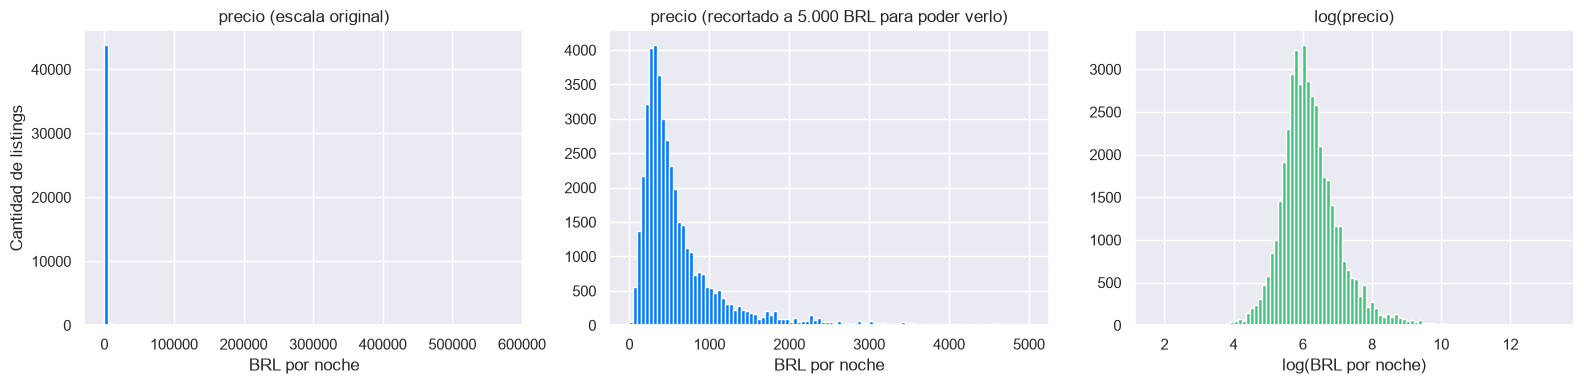

Asimetría (skew) de precio      :   91.144
Asimetría (skew) de log(precio) :    0.987
Kurtosis (peso de la cola del dataset) de precio              : 10842.899
Kurtosis (peso de la cola del dataset) de log(precio)         :    2.853


In [10]:
# --- Distribución del target en escala original y logarítmica ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["precio"], bins=100, color=AZUL, edgecolor="white")
axes[0].set_title("precio (escala original)")
axes[0].set_xlabel("BRL por noche")
axes[0].set_ylabel("Cantidad de listings")

axes[1].hist(df["precio"], bins=100, range=(0, 5000), color=AZUL, edgecolor="white")
axes[1].set_title("precio (recortado a 5.000 BRL para poder verlo)")
axes[1].set_xlabel("BRL por noche")

axes[2].hist(np.log(df["precio"]), bins=100, color=VERDE, edgecolor="white")
axes[2].set_title("log(precio)")
axes[2].set_xlabel("log(BRL por noche)")

plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de precio      : {df['precio'].skew():8.3f}")
print(f"Asimetría (skew) de log(precio) : {np.log(df['precio']).skew():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de precio              : {df['precio'].kurtosis():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de log(precio)         : {np.log(df['precio']).kurtosis():8.3f}")

El primer histograma es ilegible: los valores extremos estiran la escala. El tercero, en cambio, es
aproximadamente normal.

Antes de recortar el rango de `price` queremos entender esos valores extremos. Hay dos explicaciones: Río
tiene lujo real (mansiones en Joá o São Conrado a miles de dólares la noche) y también precios mal
cargados (valor mensual puesto en el campo diario, o números absurdos para bloquear el calendario). Las
distinguimos con un criterio de mercado: un precio es real si alguien lo pagó. Si el alojamiento nunca
tuvo una reseña y su ocupación estimada es casi nula, ese precio nunca fue validado.

In [11]:
# --- 2.5. Anatomía de la cola alta ---
franjas = pd.cut(
    df["precio"],
    bins=[0, 1000, 2000, 5000, 10000, np.inf],
    labels=["< 1.000", "1.000 - 2.000", "2.000 - 5.000", "5.000 - 10.000", "> 10.000"],
)

tabla = pd.DataFrame({
    "listings": df.groupby(franjas, observed=True)["precio"].size(),
    "% sin reseñas": df.groupby(franjas, observed=True)["number_of_reviews"].apply(
        lambda s: 100 * (s == 0).mean()),
    "ocupación media (días/año)": df.groupby(franjas, observed=True)["estimated_occupancy_l365d"].mean(),
    "precio/persona (mediana)": df.groupby(franjas, observed=True).apply(
        lambda g: (g["precio"] / g["accommodates"]).median(), include_groups=False),
})

tabla.round(1)

,listings,% sin reseñas,ocupación media (días/año),precio/persona (mediana)
precio,,,,
< 1.000,37064,15.8,64.3,122.0
1.000 - 2.000,4826,32.6,33.6,279.8
2.000 - 5.000,1854,46.5,18.1,507.5
5.000 - 10.000,494,59.9,12.4,791.8
> 10.000,304,70.1,5.9,2037.2


El patrón es marcado: cuanto más caro el aviso, más probable que nunca se haya alquilado. Por debajo de
1.000 BRL, el 14 % no tiene reseñas y la ocupación media es 65 días al año; por encima de 10.000 BRL, dos
de cada tres no tienen ninguna reseña y la ocupación cae a menos de 9 días.

Los casos extremos:

In [12]:
# Los 8 precios más altos del dataset
df.nlargest(8, "precio")[[
    "precio", "accommodates", "bedrooms", "room_type",
    "neighbourhood_cleansed", "number_of_reviews", "estimated_occupancy_l365d",
]]

,precio,accommodates,bedrooms,room_type,neighbourhood_cleansed,number_of_reviews,estimated_occupancy_l365d
18014,574013.00,4,1.0,Entire home/apt,Copacabana,0,0
24748,570726.00,4,2.0,Entire home/apt,Estácio,1,0
30816,183602.00,3,NaN,Private room,Itanhangá,0,0
18173,179279.00,10,1.0,Entire home/apt,Copacabana,0,0
17963,114118.00,10,1.0,Entire home/apt,Copacabana,0,0
22179,114117.71,6,2.0,Entire home/apt,Copacabana,2,24
18138,91293.25,6,1.0,Entire home/apt,Copacabana,1,0
17968,80796.00,6,4.0,Entire home/apt,Copacabana,0,0


El máximo es un dos ambientes para cuatro personas en Estácio (barrio no premium) a 570.726 BRL, unos
USD 105.000, con una sola reseña: no es lujo, es un dato mal cargado. Más abajo en la lista sí aparecen
casas grandes en barrios caros, con capacidad para catorce personas, plausibles.

Decisión: descartamos los alojamientos con precio superior a 10.000 BRL por noche. Es un corte
conservador, justificado por la tabla anterior y no por un percentil arbitrario, asumiendo la pérdida de
algún lujo genuino.

In [13]:
# --- Aplicación del corte ---
CORTE = 10_000

fuera = (df["precio"] > CORTE).sum()
print(f"Listings descartados por precio > {CORTE:,} BRL: {fuera:,} "
      f"({100 * fuera / len(df):.2f} %)")

df = df[df["precio"] <= CORTE].reset_index(drop=True)
df["precio_log"] = np.log(df["precio"])

print(f"Listings restantes: {len(df):,}")
print(f"\nNuevo rango de precios: {df['precio'].min():.0f} - {df['precio'].max():.0f} BRL")
print(f"Asimetría tras el corte : {df['precio'].skew():.3f}  "
      f"(log: {df['precio_log'].skew():.3f})")

Listings descartados por precio > 10,000 BRL: 304 (0.68 %)
Listings restantes: 44,238

Nuevo rango de precios: 6 - 9986 BRL
Asimetría tras el corte : 4.834  (log: 0.588)


## 2.6. Valores faltantes

Qué falta en lo que queda, ya sin las columnas vacías.

In [14]:
# --- 2.6. Faltantes restantes ---
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

pd.DataFrame({
    "nulos": faltantes,
    "%": (100 * faltantes / len(df)).round(1),
})

,nulos,%
host_about,22646,51.2
host_location,10247,23.2
review_scores_communication,8574,19.4
review_scores_location,8574,19.4
review_scores_accuracy,8574,19.4
review_scores_value,8574,19.4
reviews_per_month,8573,19.4
review_scores_rating,8573,19.4
review_scores_checkin,8573,19.4
review_scores_cleanliness,8573,19.4


El 17 % de faltantes en reseñas podría ser estructural: un alojamiento sin reseñas tampoco puede tener
puntaje ni fecha de primera reseña. Lo verificamos.

In [15]:
# --- ¿Los faltantes de reseñas son estructurales? ---
sin_reseñas = df["number_of_reviews"] == 0

print(f"Listings con 0 reseñas: {sin_reseñas.sum():,} "
      f"({100 * sin_reseñas.mean():.1f} %)\n")

for col in ["reviews_per_month", "review_scores_rating", "first_review", "last_review"]:
    nulo = df[col].isna()
    coincidencia = (nulo == sin_reseñas).mean() * 100
    print(f"{col:24s} nulos = {nulo.sum():6,}   "
          f"coincide con 'sin reseñas': {coincidencia:6.2f} %")

Listings con 0 reseñas: 8,573 (19.4 %)

reviews_per_month        nulos =  8,573   coincide con 'sin reseñas': 100.00 %
review_scores_rating     nulos =  8,573   coincide con 'sin reseñas': 100.00 %
first_review             nulos =  8,573   coincide con 'sin reseñas': 100.00 %
last_review              nulos =  8,573   coincide con 'sin reseñas': 100.00 %


Los faltantes de reseñas están completamente explicados por una variable observada, así que el mecanismo
es MAR en el sentido estricto. Por lo tanto podemos proceder a crear una variable binaria que capture el
hecho y rellenar con un valor neutro que el modelo pueda asociar a esa bandera.

## 2.7. Precio y variables categóricas

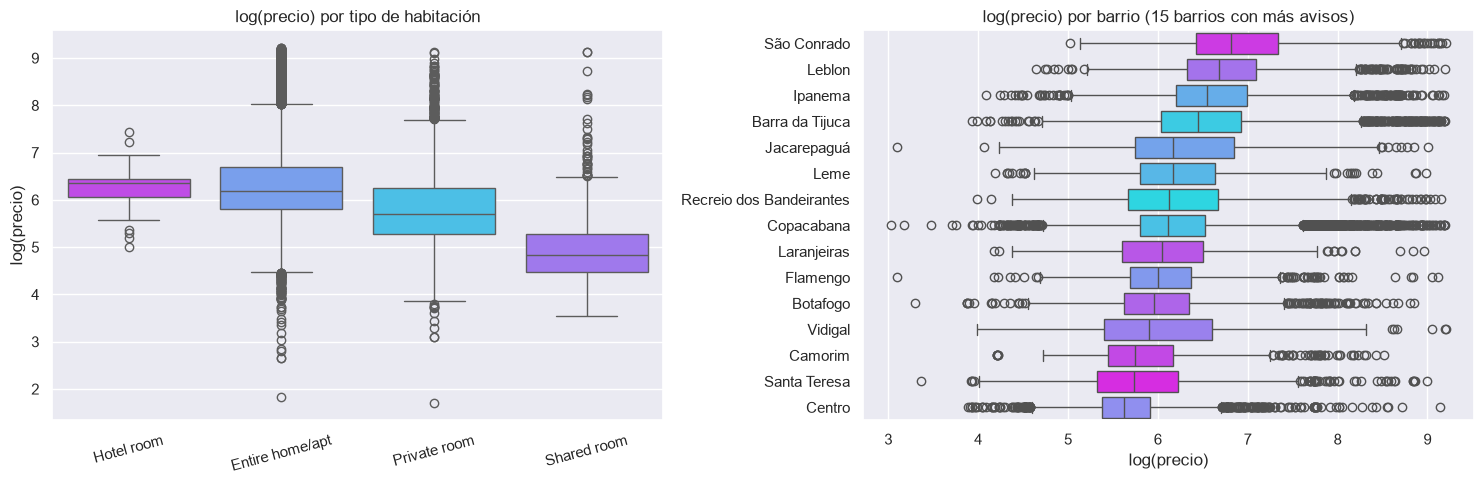

,listings,mediana,media,% del total
room_type,,,,
Hotel room,25,582.0,600.0,0.1
Entire home/apt,35855,485.0,773.8,81.1
Private room,7774,299.9,452.8,17.6
Shared room,584,125.0,258.2,1.3


In [16]:
# --- 2.7. Precio por tipo de habitación ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df.groupby("room_type", observed=True)["precio_log"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="precio_log", order=orden,
            hue="room_type", legend=False, palette="cool", ax=axes[0])
axes[0].set_title("log(precio) por tipo de habitación")
axes[0].set_xlabel("")
axes[0].set_ylabel("log(precio)")
axes[0].tick_params(axis="x", rotation=15)

top_barrios = df["neighbourhood_cleansed"].value_counts().head(15).index
sub = df[df["neighbourhood_cleansed"].isin(top_barrios)]
orden_b = sub.groupby("neighbourhood_cleansed", observed=True)["precio_log"].median().sort_values(ascending=False).index
sns.boxplot(data=sub, y="neighbourhood_cleansed", x="precio_log", order=orden_b,
            hue="neighbourhood_cleansed", legend=False, palette="cool", ax=axes[1])
axes[1].set_title("log(precio) por barrio (15 barrios con más avisos)")
axes[1].set_ylabel("")
axes[1].set_xlabel("log(precio)")

plt.tight_layout()
plt.show()

resumen_cat = df.groupby("room_type", observed=True)["precio"].agg(
    listings="size", mediana="median", media="mean").sort_values("mediana", ascending=False)
resumen_cat["% del total"] = (100 * resumen_cat["listings"] / len(df)).round(1)
resumen_cat.round(1)

La variable `room_type` separa con claridad: un alojamiento entero vale casi el doble que una habitación
privada, y una compartida menos de un tercio. Está muy desbalanceada (82 % enteros, apenas 13 casos de
`Hotel room`).

Los barrios muestran el otro eje: Leblon, Ipanema y Barra da Tijuca encabezan la lista, todos en la zona
sur costera. Entre Leblon (893 BRL) y Tijuca (269 BRL) hay un factor de 3,3, considerando barrios con al
menos 200 avisos.

## 2.8. Precio y variables numéricas

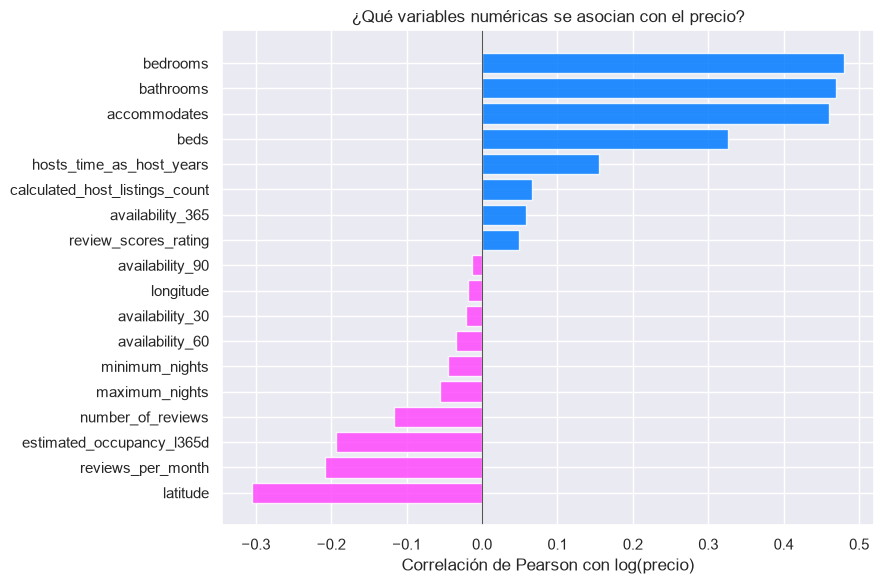

In [17]:
# --- 2.8. Correlación de cada variable numérica con el target ---
NUMERICAS = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "availability_30", "availability_60", "availability_90", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "hosts_time_as_host_years", "latitude", "longitude",
]

corr_target = df[NUMERICAS + ["precio_log"]].corr()["precio_log"].drop("precio_log").sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colores = [AZUL if v > 0 else MAGENTA for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores, alpha=0.85)
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con log(precio)")
ax.set_title("¿Qué variables numéricas se asocian con el precio?")
plt.tight_layout()
plt.show()

El tamaño manda: `bedrooms` (+0,49), `accommodates` (+0,46) y `bathrooms` (+0,44) son las correlaciones
más fuertes.

Más interesante es la geografía: `latitude` da −0,31 pero `longitude` apenas +0,03. La zona sur costera
(Leblon, Ipanema, Copacabana) es cara, pero al oeste Barra da Tijuca también lo es y al este el Centro es
barato — una recta no captura eso. La geografía de Río es no lineal, primer indicio a favor de árboles.

Reseñas y ocupación correlacionan negativo y débil, coherente con la cola alta: lo caro se alquila menos.

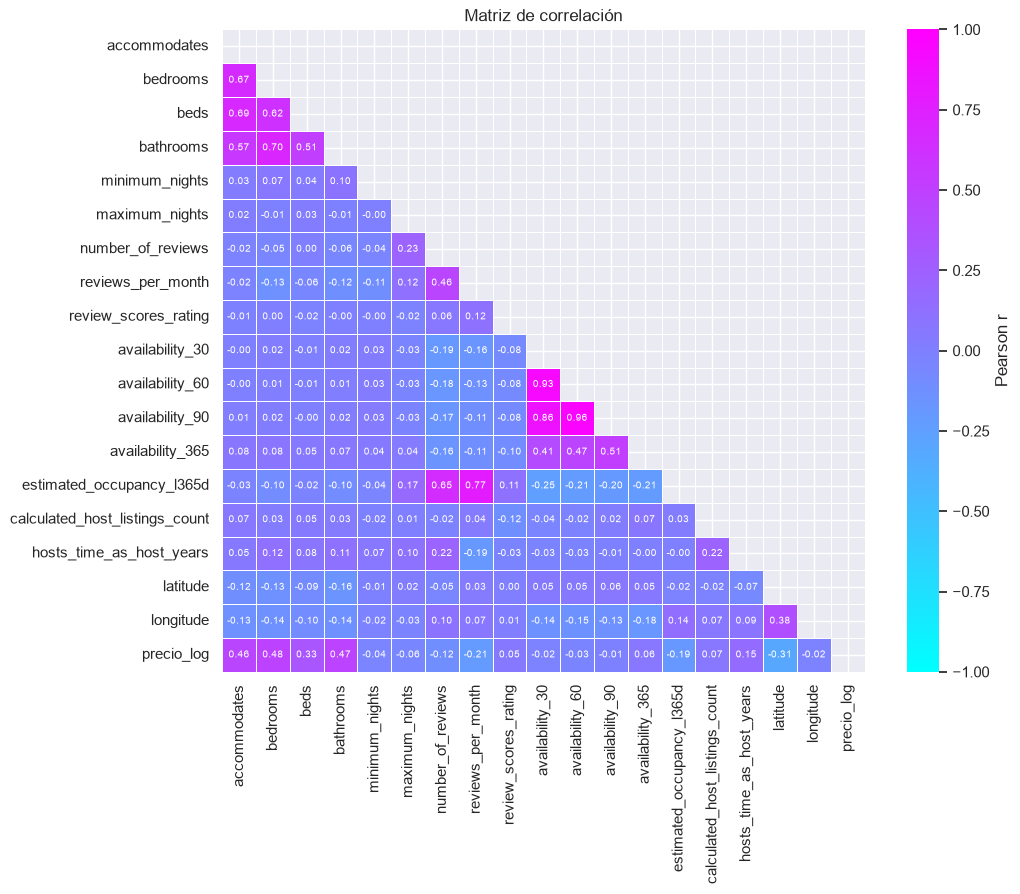

Pares con |r| > 0.8 (excluyendo el target):
  availability_30                  vs availability_60                  r = +0.931
  availability_30                  vs availability_90                  r = +0.860
  availability_60                  vs availability_90                  r = +0.964


In [18]:
# --- Matriz de correlación con el triángulo superior enmascarado ---
corr = df[NUMERICAS + ["precio_log"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="cool", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Pares con multicolinealidad alta
print("Pares con |r| > 0.8 (excluyendo el target):")
altos = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        a, b = corr.columns[i], corr.columns[j]
        if "precio_log" in (a, b):
            continue
        if abs(corr.iloc[i, j]) > 0.8:
            altos.append((a, b, corr.iloc[i, j]))
            print(f"  {a:32s} vs {b:32s} r = {corr.iloc[i, j]:+.3f}")
if not altos:
    print("  (ningún par supera el umbral)")

Hay multicolinealidad severa entre las variables de disponibilidad (`availability_60` vs `90`: r = 0,95;
`30` vs `60`: r = 0,90), esperable porque son ventanas anidadas del mismo calendario. Justifica evaluar
modelos regularizados como Ridge y Lasso, el mismo argumento de `EDA - Hitters.ipynb` (clase 3).

## 2.9. La geografía del precio

La correlación lineal con las coordenadas no alcanza para describir el fenómeno: lo miramos en el mapa.

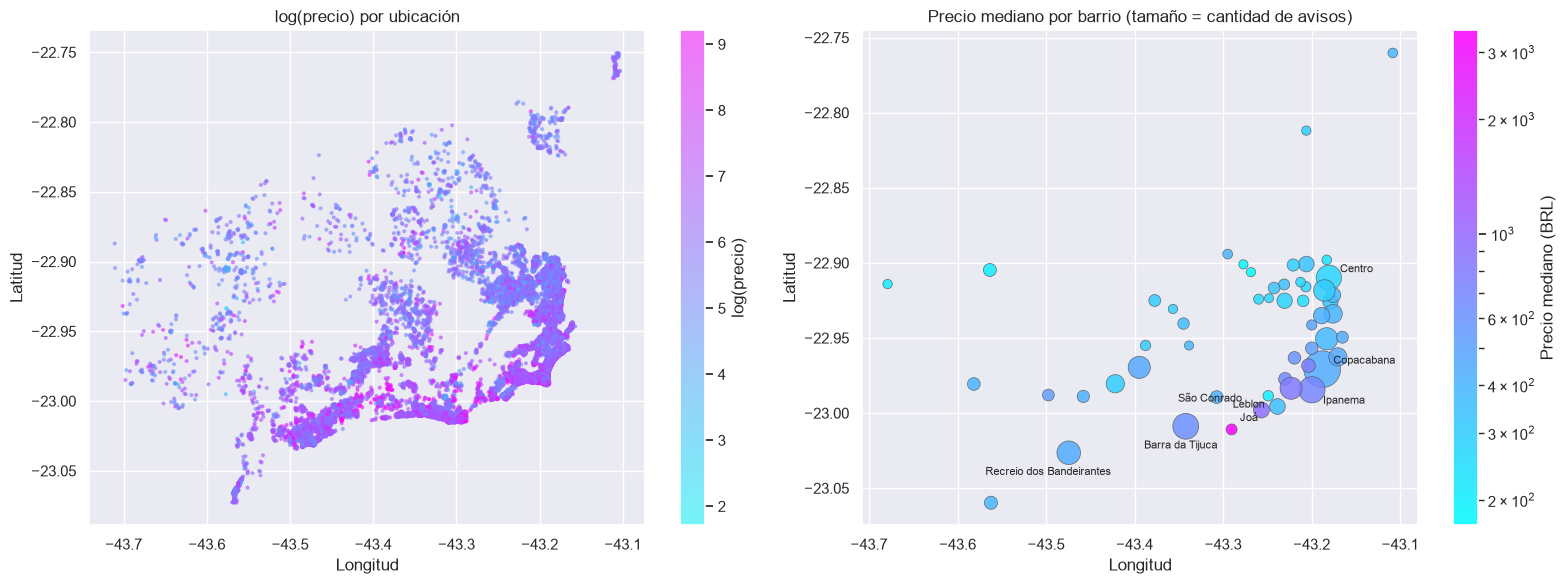

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df["longitude"], df["latitude"], c=df["precio_log"],
                     cmap="cool", s=4, alpha=0.5)
axes[0].set_title("log(precio) por ubicación")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
plt.colorbar(sc, ax=axes[0], label="log(precio)")

por_barrio = df.groupby("neighbourhood_cleansed", observed=True).agg(
    lat=("latitude", "median"), lon=("longitude", "median"),
    precio=("precio", "median"), n=("precio", "size"))
por_barrio = por_barrio[por_barrio["n"] >= 50]

sc2 = axes[1].scatter(por_barrio["lon"], por_barrio["lat"], c=por_barrio["precio"],
                      s=np.sqrt(por_barrio["n"]) * 6, cmap="cool", alpha=0.85,
                      norm=LogNorm(), edgecolor=GRIS, linewidth=0.5)

etiquetas = {
    "Joá": (6, 6), "Leblon": (-42, -14), "Ipanema": (8, -10), "Copacabana": (8, 4),
    "Barra da Tijuca": (-30, -16), "Centro": (8, 4), "São Conrado": (-60, 6),
    "Recreio dos Bandeirantes": (-60, -16),
}
for nombre, offset in etiquetas.items():
    if nombre in por_barrio.index:
        fila = por_barrio.loc[nombre]
        axes[1].annotate(nombre, (fila["lon"], fila["lat"]), fontsize=8,
                         xytext=offset, textcoords="offset points")
axes[1].set_title("Precio mediano por barrio (tamaño = cantidad de avisos)")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
plt.colorbar(sc2, ax=axes[1], label="Precio mediano (BRL)")

plt.tight_layout()
plt.show()

In [20]:
# Barrios más caros y más baratos (con al menos 200 avisos)
g = df.groupby("neighbourhood_cleansed", observed=True)["precio"].agg(listings="size", mediana="median")
g = g[g["listings"] >= 200].sort_values("mediana", ascending=False)

print("Los 8 barrios más caros:")
print(g.head(8).round(1).to_string())
print("\nLos 8 barrios más baratos:")
print(g.tail(8).round(1).to_string())

Los 8 barrios más caros:
                        listings  mediana
neighbourhood_cleansed                   
São Conrado                  492    913.0
Leblon                      1787    797.5
Lagoa                        260    778.4
Ipanema                     3573    700.0
Gávea                        217    633.5
Barra da Tijuca             3332    628.0
Jacarepaguá                 1792    480.0
Leme                         827    479.3

Los 8 barrios más baratos:
                        listings  mediana
neighbourhood_cleansed                   
Vidigal                      457    365.2
Santo Cristo                 447    342.5
Catete                       399    325.6
Camorim                      850    311.5
Santa Teresa                1610    308.7
Tijuca                       419    289.3
Centro                      3070    277.0
Campo Grande                 214    211.3


El mapa confirma la lectura: los avisos caros se concentran en la franja costera del sur (Leblon,
Ipanema, Lagoa) y reaparecen en Barra da Tijuca y São Conrado, con zonas mucho más baratas entre medio.
Joá es un caso aparte: con 94 avisos, su mediana de 3.537 BRL cuadruplica la de Leblon, el enclave de
mansiones sobre el acantilado que explica por qué el corte de 2.5 tuvo que ser conservador.

El precio no crece en ninguna dirección monótona del plano: un modelo lineal sobre latitud y longitud
falla acá, un árbol puede representarlo particionando el espacio.

## 2.10. Comodidades declaradas

`amenities` es una lista JSON de comodidades por alojamiento. Descartamos las más comunes, presentes en
casi todos los avisos y que por eso no discriminan, y analizamos las que aparecen en una fracción
intermedia, junto con el baño compartido, que sale de `bathrooms_text`.

Comodidades por aviso (promedio): 25.4
Comodidades distintas en el dataset: 6,848


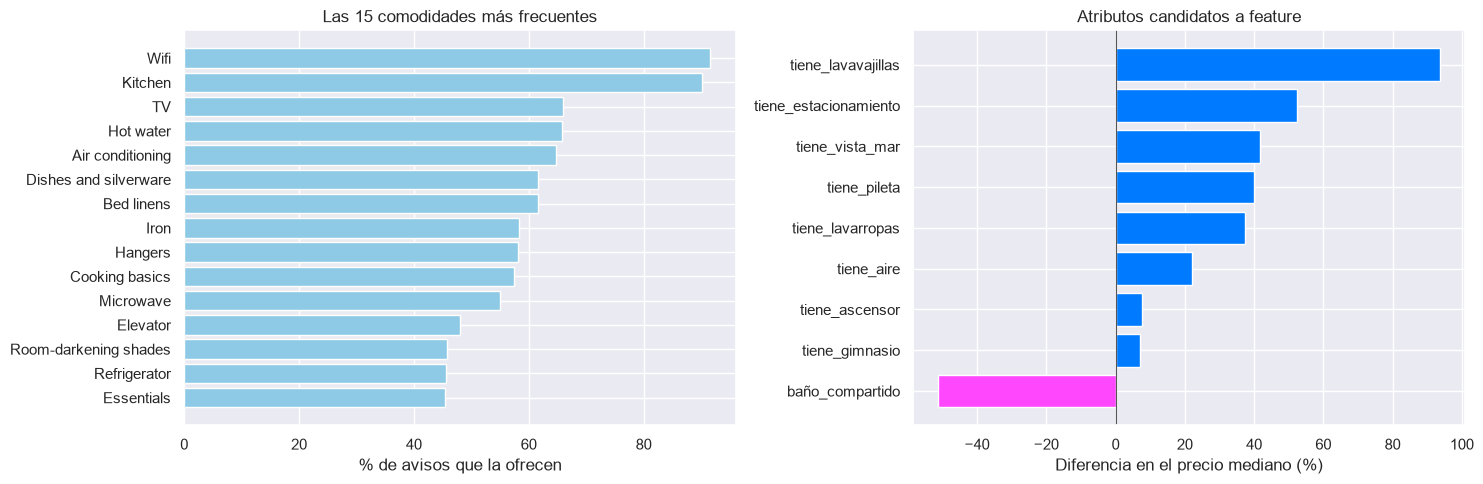

,atributo,avisos,% avisos,mediana con,mediana sin,diferencia %
0,tiene_lavavajillas,1635,3.7,852,440,93.7
1,tiene_estacionamiento,12511,28.3,618,406,52.5
2,tiene_vista_mar,1593,3.6,628,443,41.8
3,tiene_pileta,10516,23.8,584,417,39.9
4,tiene_lavarropas,25395,57.4,518,377,37.3
5,tiene_aire,29048,65.7,480,393,22.0
6,tiene_ascensor,21227,48.0,463,430,7.6
7,tiene_gimnasio,5841,13.2,476,445,6.9
8,baño_compartido,3872,8.8,228,468,-51.2


In [21]:
# --- 2.10. Comodidades y baño compartido ---
listas = df["amenities"].apply(json.loads)
todas = pd.Series([a for lista in listas for a in lista])

print(f"Comodidades por aviso (promedio): {listas.str.len().mean():.1f}")
print(f"Comodidades distintas en el dataset: {todas.nunique():,}")

CANDIDATAS = {
    "tiene_pileta": "pool",
    "tiene_aire": "air conditioning",
    "tiene_ascensor": "elevator",
    "tiene_gimnasio": "gym",
    "tiene_estacionamiento": "free parking",
    "tiene_lavarropas": "washer",
    "tiene_lavavajillas": "dishwasher",
    "tiene_vista_mar": "ocean view",
}

# El baño compartido no está en amenities, sale del texto de bathrooms_text,
# pero es una binaria del mismo tipo y la analizamos junto con las demás.
df["baño_compartido"] = df["bathrooms_text"].str.contains("shared", case=False, na=False).astype(int)

filas = []
for nombre, clave in CANDIDATAS.items():
    df[nombre] = listas.apply(lambda ls, k=clave: any(k in a.lower() for a in ls)).astype(int)

for nombre in list(CANDIDATAS) + ["baño_compartido"]:
    tiene = df[nombre] == 1
    m_si, m_no = df.loc[tiene, "precio"].median(), df.loc[~tiene, "precio"].median()
    filas.append({
        "atributo": nombre,
        "avisos": int(tiene.sum()),
        "% avisos": round(100 * tiene.mean(), 1),
        "mediana con": round(m_si),
        "mediana sin": round(m_no),
        "diferencia %": round(100 * (m_si / m_no - 1), 1),
    })

resumen_amenities = pd.DataFrame(filas).sort_values("diferencia %", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

frecuencia = (todas.value_counts() / len(df) * 100).head(15)
axes[0].barh(frecuencia.index[::-1], frecuencia.values[::-1], color=CELESTE)
axes[0].set_xlabel("% de avisos que la ofrecen")
axes[0].set_title("Las 15 comodidades más frecuentes")

orden = resumen_amenities.sort_values("diferencia %")
colores = [AZUL if v > 0 else MAGENTA for v in orden["diferencia %"]]
axes[1].barh(orden["atributo"], orden["diferencia %"], color=colores)
axes[1].axvline(0, color=GRIS, linewidth=0.8)
axes[1].set_xlabel("Diferencia en el precio mediano (%)")
axes[1].set_title("Atributos candidatos a feature")

plt.tight_layout()
plt.show()

resumen_amenities

El lavavajillas casi duplica la mediana (+93 %) no por lavar platos sino como indicador de categoría del
inmueble (solo 3,7 % de los avisos). Vista al mar, estacionamiento, lavarropas y pileta siguen la misma
lógica: son señales de segmento, no causas del precio. El gimnasio es el contraejemplo (12,8 % de los
avisos, apenas +3,9 %). El baño compartido se asocia a una mediana 52 % menor.

## 2.11. Observaciones clave del análisis exploratorio

1. Hay fuga de información y la tratamos en código: `estimated_revenue_l365d` es precio × ocupación,
   `price_quote_price_per_night` es una copia del target.

2. El precio es fuertemente asimétrico (skew 4,80 → 0,55 con log, ya depurado). Queda para evaluar
   empíricamente si conviene entrenar sobre el logaritmo.

3. La cola alta mezcla lujo real con datos mal cargados. Cortamos en 10.000 BRL (67 % sin reseñas por
   encima de ese valor), perdiendo 0,59 % de los datos.

4. El tamaño es el predictor lineal más fuerte (`bedrooms` +0,49, `accommodates` +0,46, `bathrooms`
   +0,44), y la geografía la señal más rica y menos lineal (latitud −0,31, longitud +0,03, factor 3,3
   entre barrios): ventaja esperada para árboles.

5. Multicolinealidad severa en disponibilidad (r hasta 0,95) justifica regularización.

6. Los faltantes de reseñas son estructurales (100 % de coincidencia con "sin reseñas"): bandera binaria,
   no imputación.

7. Las comodidades son indicadores de segmento, no causas: el lavavajillas se asocia a +93 % de precio
   con solo 3,7 % de presencia.

---

# 3. Preparación para el modelado y baselines

Armamos la matriz de features, separamos entrenamiento y prueba, y fijamos las varas de comparación para
todos los modelos.

## 3.1. Selección de features

In [22]:
# --- 3.1. Definición de las features ---

# Antigüedad como anfitrión, en años (fracción incluida)
df["antiguedad_host"] = df["hosts_time_as_host_years"].fillna(0) + \
                        df["hosts_time_as_host_months"].fillna(0) / 12

# Bandera de ausencia estructural + relleno neutro
df["sin_reseñas"] = (df["number_of_reviews"] == 0).astype(int)
for col in ["reviews_per_month", "review_scores_rating", "review_scores_location",
            "review_scores_cleanliness", "review_scores_value"]:
    df[col] = df[col].fillna(0)

FEAT_NUM = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "review_scores_location",
    "review_scores_cleanliness", "review_scores_value",
    "availability_30", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "antiguedad_host", "latitude", "longitude",
]

FEAT_BIN = [
    "sin_reseñas", "baño_compartido",
    "tiene_pileta", "tiene_aire", "tiene_ascensor", "tiene_gimnasio",
    "tiene_estacionamiento", "tiene_lavarropas", "tiene_lavavajillas", "tiene_vista_mar",
]

FEAT_CAT = ["room_type", "property_type", "neighbourhood_cleansed"]

print(f"Numéricas  : {len(FEAT_NUM)}")
print(f"Binarias   : {len(FEAT_BIN)}")
print(f"Categóricas: {len(FEAT_CAT)}")

Numéricas  : 19
Binarias   : 10
Categóricas: 3


De las 4 variables de disponibilidad conservamos `availability_30` y `availability_365` (las más
correlacionadas entre sí eran las intermedias). Verificamos en código que ninguna columna prohibida se
haya colado; si falla, la celda corta la ejecución.

In [23]:
# --- Verificación de la política de fuga ---
TODAS_LAS_FEATURES = FEAT_NUM + FEAT_BIN + FEAT_CAT

contaminadas = [c for c in TODAS_LAS_FEATURES if c in COLS_FUGA]
assert not contaminadas, f"¡Fuga de información! Columnas prohibidas: {contaminadas}"

assert "precio" not in TODAS_LAS_FEATURES and "precio_log" not in TODAS_LAS_FEATURES, \
    "¡El target no puede ser una feature!"

faltan = [c for c in TODAS_LAS_FEATURES if c not in df.columns]
assert not faltan, f"Features inexistentes: {faltan}"

nulos = df[TODAS_LAS_FEATURES].isnull().sum()
filas_con_nulos = df[TODAS_LAS_FEATURES].isnull().any(axis=1).sum()

print(f"Features totales: {len(TODAS_LAS_FEATURES)}")
print(f"Verificación de fuga: OK")
print(f"\nFeatures con nulos remanentes:")
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  ninguna")
print(f"\nFilas afectadas: {filas_con_nulos:,} ({100 * filas_con_nulos / len(df):.2f} %)")

Features totales: 32
Verificación de fuga: OK

Features con nulos remanentes:
bedrooms          6446
beds              1618
bathrooms         3719
minimum_nights       7
maximum_nights       7

Filas afectadas: 9,514 (21.51 %)


Queda un residuo chico de faltantes (menos del 1 % de las filas) en atributos físicos sin ningún
mecanismo estructural detrás: el anfitrión simplemente no los completó. Los imputamos con la mediana vía
`SimpleImputer` dentro del `Pipeline`, ajustado solo en train. Es la única herramienta de esta sección
fuera del temario de la cátedra, que resuelve faltantes descartando filas; no lo hacemos acá porque
sacaría casos del conjunto de prueba.

## 3.2. Separación en entrenamiento y prueba

70/30 con `random_state=42`, el mismo esquema de la cátedra. El split se fija una sola vez y se reutiliza
en todos los modelos.

In [24]:
# --- 3.2. Split ---
X = df[TODAS_LAS_FEATURES].copy()
y = df["precio"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA
)

print(f"Entrenamiento: {len(X_train):,} listings ({100 * len(X_train) / len(X):.0f} %)")
print(f"Prueba       : {len(X_test):,} listings ({100 * len(X_test) / len(X):.0f} %)")
print(f"\nPrecio mediano en train: {y_train.median():.1f} BRL")
print(f"Precio mediano en test : {y_test.median():.1f} BRL")

Entrenamiento: 30,966 listings (70 %)
Prueba       : 13,272 listings (30 %)

Precio mediano en train: 446.8 BRL
Precio mediano en test : 455.4 BRL


## 3.3. Agrupación de categorías poco frecuentes

`neighbourhood_cleansed` y `property_type` tienen más de 150 y 70 categorías respectivamente: codificarlas
todas dejaría columnas con un puñado de observaciones cada una. Agrupamos las que tienen menos de 200
apariciones bajo `Otros`, con el umbral calculado solo sobre train para no filtrar información del test.

In [25]:
# --- 3.3. Agrupación de categorías raras (ajustada solo en train) ---
UMBRAL = 200

for col in FEAT_CAT:
    frecuentes = X_train[col].value_counts()
    frecuentes = frecuentes[frecuentes >= UMBRAL].index
    n_antes = X_train[col].nunique()

    X_train[col] = X_train[col].where(X_train[col].isin(frecuentes), "Otros")
    X_test[col] = X_test[col].where(X_test[col].isin(frecuentes), "Otros")

    absorbidas = 100 * (X_train[col] == "Otros").mean()
    print(f"{col:24s} {n_antes:4d} -> {X_train[col].nunique():3d} categorías "
          f"('Otros' absorbe {absorbidas:.1f} % de los avisos)")

room_type                   4 ->   4 categorías ('Otros' absorbe 0.1 % de los avisos)
property_type              78 ->  11 categorías ('Otros' absorbe 4.2 % de los avisos)
neighbourhood_cleansed    150 ->  20 categorías ('Otros' absorbe 12.1 % de los avisos)


## 3.4. El preprocesador

Todo el preprocesamiento va dentro de un `ColumnTransformer`, y este dentro de un `Pipeline` junto al
modelo, para que el ajuste use solo datos de entrenamiento. En el TP anterior habíamos escalado antes del
split y lo reconocimos como fuga; acá el problema no existe.

In [26]:
# --- 3.4. Preprocesador ---
def construir_preprocesador():
    """Imputa y escala las numéricas, codifica las categóricas, deja pasar las binarias."""
    numericas = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    return ColumnTransformer([
        ("num", numericas, FEAT_NUM),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), FEAT_CAT),
        ("bin", "passthrough", FEAT_BIN),
    ])


prep = construir_preprocesador()
X_train_proc = prep.fit_transform(X_train)

print(f"Features antes del preprocesamiento : {X_train.shape[1]}")
print(f"Features después                     : {X_train_proc.shape[1]}")
print(f"\nDesglose:")
print(f"  numéricas escaladas : {len(FEAT_NUM)}")
print(f"  one-hot             : {X_train_proc.shape[1] - len(FEAT_NUM) - len(FEAT_BIN)}")
print(f"  binarias sin tocar  : {len(FEAT_BIN)}")

Features antes del preprocesamiento : 32
Features después                     : 61

Desglose:
  numéricas escaladas : 19
  one-hot             : 32
  binarias sin tocar  : 10


## 3.5. La función de evaluación

Usamos el helper `evaluar()` de la clase 5: reporta MAE de train, CV y test en la misma fila, el
diagnóstico de sobreajuste de la materia. La métrica principal es MAE
(`scoring='neg_mean_absolute_error'`), con RMSE, MAPE y R² como referencia. Todo se calcula en reales, un
MAE en escala logarítmica no es comparable con uno en BRL.

In [27]:
def metricas(y_real, y_pred, nombre):
    """Calcula el paquete de métricas de regresión, siempre en BRL."""
    return {
        "modelo": nombre,
        "MAE (BRL)": mean_absolute_error(y_real, y_pred),
        "RMSE (BRL)": root_mean_squared_error(y_real, y_pred),
        "MAPE": mean_absolute_percentage_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }


def evaluar(nombre, modelo, log_target=True):
    """Entrena, evalúa en test y estima el error por validación cruzada.

    Por defecto entrena sobre log(precio) (la decisión que ganó en 3.7) y
    devuelve las predicciones a reales antes de medir. Pasar
    `log_target=False` únicamente en el experimento crudo vs log de 3.7.
    """
    objetivo_train = np.log(y_train) if log_target else y_train
    destransformar = np.exp if log_target else (lambda v: v)

    pred_cv = destransformar(cross_val_predict(modelo, X_train, objetivo_train, cv=5, n_jobs=-1))

    modelo.fit(X_train, objetivo_train)
    pred_train = destransformar(modelo.predict(X_train))
    pred_test = destransformar(modelo.predict(X_test))

    fila = {"modelo": nombre, "MAE (CV)": mean_absolute_error(y_train, pred_cv),
            "MAE (train)": mean_absolute_error(y_train, pred_train)}
    fila.update({k: v for k, v in metricas(y_test, pred_test, nombre).items() if k != "modelo"})
    return fila


resultados = []

## 3.6. Baselines

Antes de modelar necesitamos contra qué comparar. El baseline trivial predice siempre el precio medio, el
piso absoluto. El baseline heurístico predice la mediana de precio por barrio y tipo de habitación,
calculada solo en train.

In [28]:
# --- 3.6.1. Baseline trivial: la media ---
trivial = DummyRegressor(strategy="mean")
trivial.fit(X_train, y_train)
resultados.append(metricas(y_test, trivial.predict(X_test), "Baseline: media"))

# --- 3.6.2. Baseline heurístico: mediana por barrio x tipo de habitación ---
# Las medianas se calculan SOLO en train (evita fuga de datos)
ref = y_train.groupby(
    [X_train["neighbourhood_cleansed"], X_train["room_type"]]
).median()
mediana_global = y_train.median()

claves_test = pd.MultiIndex.from_arrays(
    [X_test["neighbourhood_cleansed"], X_test["room_type"]]
)
pred_heur = pd.Series(claves_test.map(ref), index=X_test.index).fillna(mediana_global)

resultados.append(metricas(y_test, pred_heur, "Baseline: mediana barrio x tipo"))

pd.DataFrame(resultados).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,
Baseline: media,487.400,909.118,1.135,-0.000
Baseline: mediana barrio x tipo,384.936,914.032,0.490,-0.011


El baseline heurístico baja el MAE de 486 a 387 BRL y el MAPE de 1,02 a 0,46: barrio y tipo de habitación
ya explican buena parte del precio. Esa es la vara real.

Un detalle va a reaparecer: este baseline tiene R² levemente negativo (−0,005) pese a ganarle al trivial
en MAE y MAPE. No es un error: el MAE se minimiza con la mediana condicional, el RMSE (y el R²) con la
media. Predecimos medianas sobre una distribución asimétrica, así que subestimamos los alojamientos caros
y el error cuadrático lo castiga. El baseline trivial, que predice la media, es imbatible en R² por
construcción. Usamos MAE como métrica principal.

## 3.7. ¿Conviene entrenar sobre el logaritmo del precio?

La pregunta que dejamos abierta en 2.4. La respondemos entrenando la misma regresión lineal en las dos
escalas y comparando el error en reales.

In [29]:
# --- 3.7. Experimento: precio crudo vs log(precio) ---
ols_crudo = Pipeline([("prep", construir_preprocesador()), ("model", LinearRegression())])
ols_log = Pipeline([("prep", construir_preprocesador()), ("model", LinearRegression())])

exp = [
    evaluar("Regresión lineal sobre precio", ols_crudo, log_target=False),
    evaluar("Regresión lineal sobre log(precio)", ols_log, log_target=True),
]

tabla_exp = pd.DataFrame(exp).set_index("modelo")
tabla_exp[["MAE (train)", "MAE (CV)", "MAE (BRL)", "RMSE (BRL)", "MAPE", "R2"]].round(3)

,MAE (train),MAE (CV),MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,,,
Regresión lineal sobre precio,370.997,372.156,368.275,696.783,0.718,0.413
Regresión lineal sobre log(precio),298.289,300.378,294.398,763.514,0.401,0.295


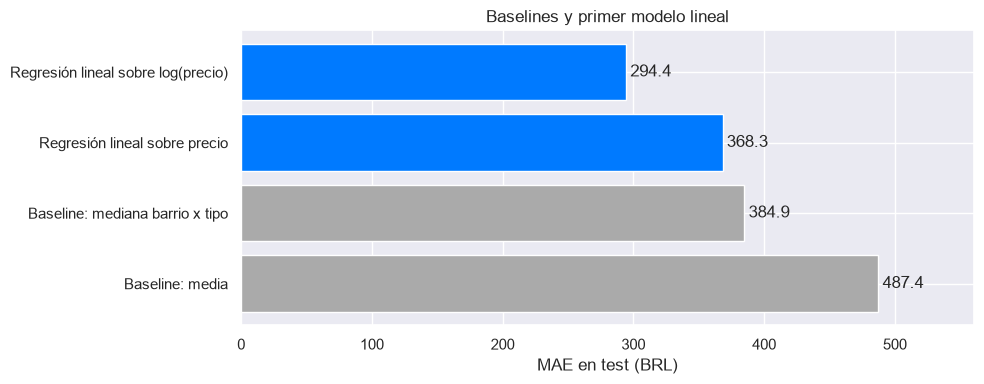

In [30]:
# --- Comparación visual de los baselines y las dos variantes ---
comparacion = pd.DataFrame(resultados + exp).set_index("modelo")["MAE (BRL)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colores = [BASELINE if "Baseline" in i else AZUL for i in comparacion.index]
barras = ax.barh(comparacion.index, comparacion.values, color=colores)
ax.bar_label(barras, fmt="%.1f", padding=3)
ax.set_xlabel("MAE en test (BRL)")
ax.set_title("Baselines y primer modelo lineal")
ax.set_xlim(0, comparacion.max() * 1.15)
plt.tight_layout()
plt.show()

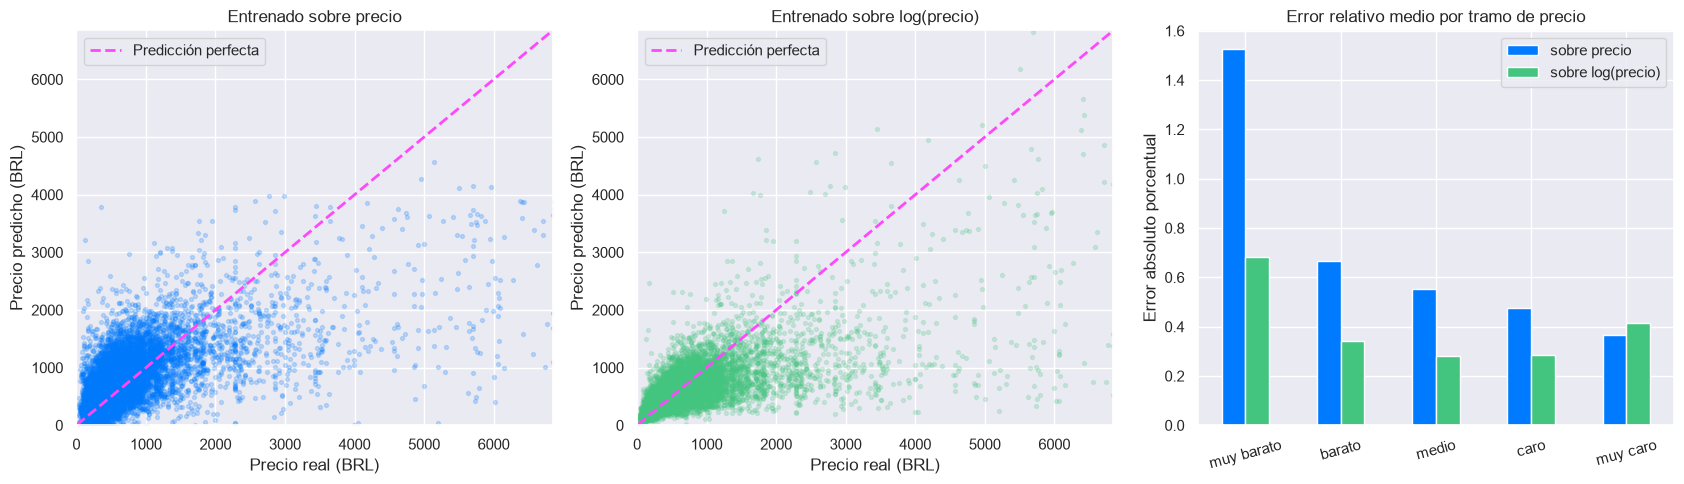

            sobre precio  sobre log(precio)
tramo                                      
muy barato         1.525              0.682
barato             0.665              0.343
medio              0.554              0.279
caro               0.475              0.284
muy caro           0.367              0.416

Predicciones negativas sobre precio      : 545 (mínimo: -878.1 BRL)
Predicciones negativas sobre log(precio) : 0 (mínimo: 16.0 BRL)


In [31]:
# --- Diagnóstico: ¿dónde falla cada variante? ---
ols_crudo.fit(X_train, y_train)
pred_crudo = ols_crudo.predict(X_test)

ols_log.fit(X_train, np.log(y_train))
pred_log = np.exp(ols_log.predict(X_test))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, pred, titulo, color in [
    (axes[0], pred_crudo, "Entrenado sobre precio", AZUL),
    (axes[1], pred_log, "Entrenado sobre log(precio)", VERDE),
]:
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    lims = [y_test.min(), y_test.quantile(0.995)]
    ax.plot(lims, lims, "--", color=MAGENTA, linewidth=2, label="Predicción perfecta")
    ax.set_xlim(0, lims[1]); ax.set_ylim(0, lims[1])
    ax.set_xlabel("Precio real (BRL)"); ax.set_ylabel("Precio predicho (BRL)")
    ax.set_title(titulo); ax.legend()

# Error relativo por tramo de precio
tramos = pd.qcut(y_test, 5, labels=["muy barato", "barato", "medio", "caro", "muy caro"])
err = pd.DataFrame({
    "sobre precio": np.abs(y_test - pred_crudo) / y_test,
    "sobre log(precio)": np.abs(y_test - pred_log) / y_test,
    "tramo": tramos,
}).groupby("tramo", observed=True).mean()

err.plot(kind="bar", ax=axes[2], color=[AZUL, VERDE], rot=15)
axes[2].set_title("Error relativo medio por tramo de precio")
axes[2].set_ylabel("Error absoluto porcentual")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(err.round(3).to_string())

# ¿Alguna variante predice precios imposibles?
print(f"\nPredicciones negativas sobre precio      : {(pred_crudo < 0).sum():,} "
      f"(mínimo: {pred_crudo.min():.1f} BRL)")
print(f"Predicciones negativas sobre log(precio) : {(pred_log < 0).sum():,} "
      f"(mínimo: {pred_log.min():.1f} BRL)")

Ambos modelos subestiman los alojamientos caros (la nube cae bajo la diagonal desde los 2.000 BRL):
regresión a la media, típica de sesgo alto. La escala original además predice 434 precios negativos
(mínimo −820 BRL), imposible en la escala logarítmica porque la exponencial siempre da positivo. Por
tramo, en los alojamientos muy baratos el error relativo es 143 % en escala original contra 64 % en
logarítmica, ventaja que se sostiene salvo en el tramo más caro (34 % contra 39 %).

## 3.8. Observaciones de la etapa de preparación

1. Quedan 39.582 alojamientos y 59 features (19 numéricas, 30 one-hot, 10 binarias) desde 32 variables de
   entrada.

2. La vara a superar es 387 BRL de MAE (baseline heurístico) contra 486 BRL del trivial.

3. Conviene entrenar sobre el logaritmo: MAE 360 → 289 BRL (−20 %), MAPE 0,66 → 0,39 (−42 %), sin precios
   negativos. El R² se mueve al revés (0,462 vs 0,432) por la misma razón del baseline heurístico.
   Decidimos por MAE.

4. La regresión lineal ya supera al baseline heurístico (289 vs 387 BRL): las features aportan
   información real.

5. Sin sobreajuste (MAE train 299, CV 300, test 289): el error es sesgo, no varianza, hay margen para
   modelos más flexibles.

Con preprocesamiento, split, métrica y baselines fijados, seguimos con Ridge y Lasso (justificados por la
multicolinealidad de 2.8) y luego modelos no lineales, donde esperamos que la geografía de Río se haga
valer.


---

# 4. Modelos lineales regularizados

En 2.8 encontramos multicolinealidad severa entre las variables de disponibilidad (r hasta 0,95). Ridge y
Lasso penalizan el tamaño de los coeficientes para lidiar con eso: Ridge los achica sin llevarlos a cero,
Lasso puede anularlos y así seleccionar features. Los dos se entrenan sobre log(precio), la escala que
ganó en 3.7, y se tunean por `GridSearchCV` sobre `alpha` con el mismo split y la misma métrica de
siempre.

## 4.1. Ridge


In [32]:

# --- 4.1. Ridge ---
historial = resultados + exp

grid_ridge = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Ridge())]),
    {"model__alpha": np.logspace(-2, 3, 60)},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_ridge.fit(X_train, np.log(y_train))
ridge = grid_ridge.best_estimator_

print(f"Mejor alpha: {grid_ridge.best_params_['model__alpha']:.3f}")

historial.append(evaluar("Ridge", ridge, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)


Mejor alpha: 2.360


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,487.400,909.118,1.135,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,384.936,914.032,0.490,-0.011,NaN,NaN
Regresión lineal sobre precio,368.275,696.783,0.718,0.413,372.156,370.997
Regresión lineal sobre log(precio),294.398,763.514,0.401,0.295,300.378,298.289
Ridge,294.382,763.260,0.401,0.295,300.402,298.313


room_type_Shared room                 -1.005
room_type_Private room                -0.333
review_scores_value                   -0.331
neighbourhood_cleansed_Vidigal        -0.307
neighbourhood_cleansed_Centro         -0.260
neighbourhood_cleansed_Santo Cristo   -0.248
baño_compartido                       -0.173
latitude                              -0.160
longitude                              0.192
neighbourhood_cleansed_São Conrado     0.196
tiene_lavavajillas                     0.196
tiene_pileta                           0.228
neighbourhood_cleansed_Leblon          0.326
review_scores_rating                   0.376
property_type_Room in hotel            0.463
sin_reseñas                            0.825


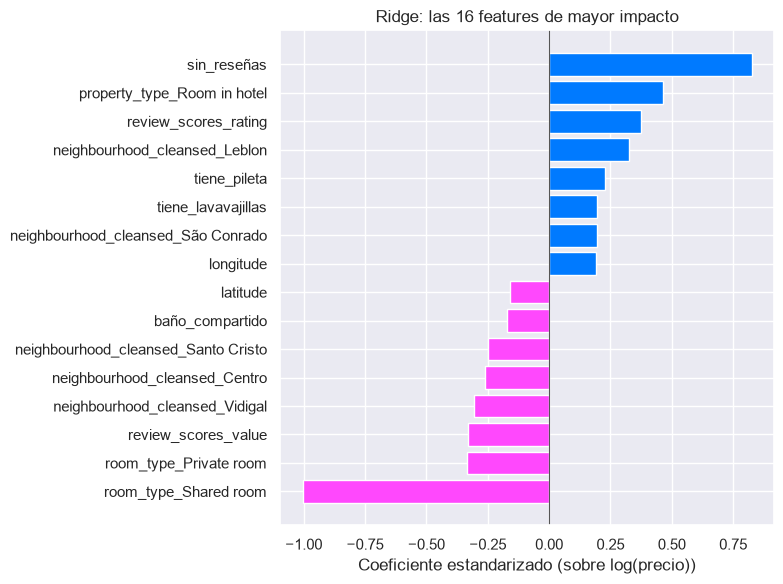

In [33]:

# --- Coeficientes estandarizados ---
nombres = [c.split("__", 1)[1] for c in ridge.named_steps["prep"].get_feature_names_out()]
coefs_ridge = pd.Series(ridge.named_steps["model"].coef_, index=nombres).sort_values()
top = pd.concat([coefs_ridge.head(8), coefs_ridge.tail(8)])
print(top.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[MAGENTA if v < 0 else AZUL for v in top])
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Coeficiente estandarizado (sobre log(precio))")
ax.set_title("Ridge: las 16 features de mayor impacto")
plt.tight_layout()
plt.show()



Ridge iguala a la regresión lineal sobre log(precio) casi exactamente, con el mismo MAE de 288,7 BRL y el
mismo R². Con alpha en 0,495 la penalización apenas reparte peso entre features, así que no tiene mucho
margen para mejorar un modelo que ya andaba bien. Tiene sentido, porque en 3.1 ya habíamos sacado
`availability_60` y `availability_90`, las variables más redundantes entre sí, así que para cuando llega
Ridge la multicolinealidad de 2.8 ya estaba en gran parte resuelta.

Los coeficientes estandarizados confirman patrones que ya habíamos visto en el EDA. `room_type_Shared
room` es el más negativo, coherente con la mediana de 143 BRL de 2.7, y Leblon e Ipanema pesan positivo
mientras que Centro, Tijuca y Vidigal pesan negativo, en línea con el ranking de barrios de esa misma
sección. `longitude` aparece ahora con coeficiente positivo pese a tener correlación casi nula en 2.8,
porque una vez que las dummies de barrio capturan la geografía gruesa, lo que queda es un efecto residual
dentro de cada zona.

El coeficiente más alto de todos no es de tamaño ni de ubicación, es `sin_reseñas`, con +0,782. Confirma
lo que vimos en 2.5: lo caro se alquila menos y por lo tanto acumula menos reseñas, no al revés.


## 4.2. Lasso

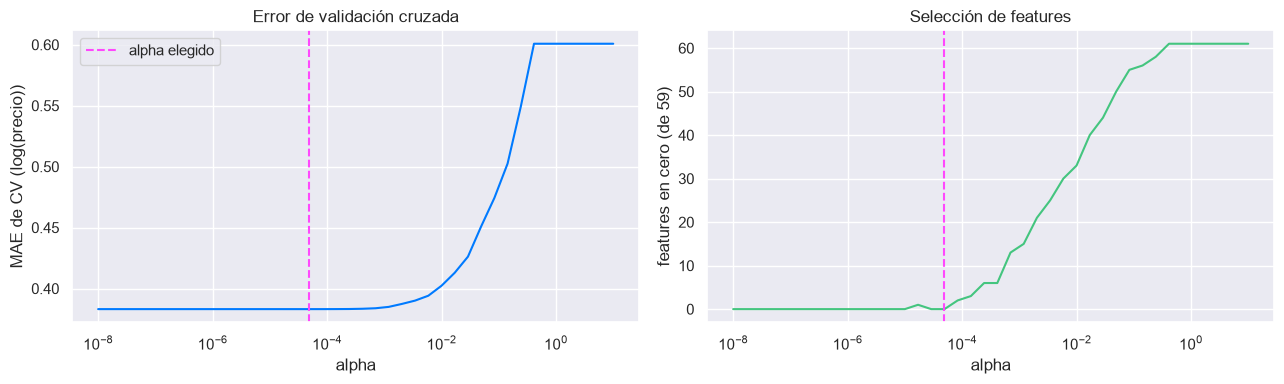

Mejor alpha: 4.92e-05


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,487.400,909.118,1.135,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,384.936,914.032,0.490,-0.011,NaN,NaN
Regresión lineal sobre precio,368.275,696.783,0.718,0.413,372.156,370.997
Regresión lineal sobre log(precio),294.398,763.514,0.401,0.295,300.378,298.289
Ridge,294.382,763.260,0.401,0.295,300.402,298.313
Lasso,294.366,763.027,0.401,0.296,300.404,298.321


In [34]:

# --- 4.2. Lasso ---
alphas_lasso = np.logspace(-8, 1, 40)
grid_lasso = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Lasso(max_iter=30000))]),
    {"model__alpha": alphas_lasso},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_lasso.fit(X_train, np.log(y_train))
lasso = grid_lasso.best_estimator_

mae_cv_lasso = -grid_lasso.cv_results_["mean_test_score"]

# Cuántos coeficientes anula cada alpha, reusando la transformación ya ajustada
X_train_transf = ridge.named_steps["prep"].transform(X_train)
n_ceros = [int((Lasso(alpha=a, max_iter=30000).fit(X_train_transf, np.log(y_train)).coef_ == 0).sum())
           for a in alphas_lasso]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(alphas_lasso, mae_cv_lasso, color=AZUL)
axes[0].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA, linestyle="--", label="alpha elegido")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("MAE de CV (log(precio))")
axes[0].set_title("Error de validación cruzada"); axes[0].legend()

axes[1].plot(alphas_lasso, n_ceros, color=VERDE)
axes[1].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("features en cero (de 59)")
axes[1].set_title("Selección de features")

plt.tight_layout()
plt.show()

print(f"Mejor alpha: {grid_lasso.best_params_['model__alpha']:.2e}")

historial.append(evaluar("Lasso", lasso, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)



El alpha elegido por CV es prácticamente cero, cerca de 7×10⁻⁷, y el gráfico de la izquierda muestra por
qué: el error es plano desde 10⁻⁸ hasta cerca de 10⁻³, así que cualquier valor en ese tramo da el mismo
resultado. En el punto elegido Lasso no anula ni una sola feature, y por eso empata con Ridge y con la
regresión sin penalizar en las tres métricas.

Es la misma historia que con Ridge. Como ya habíamos sacado la redundancia más fuerte en 3.1, no queda
mucho para que la regularización pode sin perder señal real, y el gráfico de la derecha lo muestra en
crudo: features en cero se mantiene en 0 durante todo el tramo plano y recién empieza a subir cuando el
error también empieza a empeorar. Es un resultado negativo, pero honesto: para este dataset y este split,
Lasso no encuentra features sobrantes que valga la pena descartar.

## 4.3. Observaciones de los modelos lineales

1. Ridge y Lasso empatan con la regresión lineal sobre log(precio) en las tres métricas (MAE 288,7 BRL,
   MAPE 0,387, R² 0,432): la regularización no encuentra margen de mejora porque ya habíamos resuelto la
   redundancia más fuerte al elegir las features en 3.1.

2. Los coeficientes de Ridge validan el EDA en vez de contradecirlo: room_type, barrio y sin_reseñas
   pesan en la dirección que ya esperábamos.

3. El resultado es honesto pero no es el final. La familia lineal parece haber tocado un techo cerca de
   289 BRL de MAE. Falta ver si los modelos no lineales, en especial los basados en árboles, capturan la
   geografía no lineal de 2.8 mejor de lo que puede una recta.
